# Phase 3 — Feature EDA

Four questions:
1. **Goal rate by category** — do the categorical features encode real signal?
2. **Weak foot vs right/left foot** — is `is_weak_foot` a better abstraction than separate foot flags?
3. **Spatial analysis** — distance, visible angle, and shot geography
4. **Feature correlations** — which features overlap, and do all point in the expected direction?

Input: `data/processed/03_design_matrix.parquet`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import seaborn as sns

ROOT = Path("../")
df = pd.read_parquet(ROOT / "data/processed/03_design_matrix.parquet")

print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}  |  Goal rate: {df['is_goal'].mean()*100:.2f}%")

Rows: 82,380  |  Columns: 41  |  Goal rate: 10.32%


In [2]:
# Publication-quality defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "sans-serif",
})

GOAL_COLOR  = "#e63946"   # red — goal
NO_GOAL_COLOR = "#457b9d" # blue — no goal
NEUTRAL_COLOR = "#2b2d42"
FIGDIR = ROOT / "outputs/figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

---
## 1. Goal Rate by Category

Each bar shows the conversion rate within that group. The dashed line is the overall baseline (10.3%). Error bars are 95% Wilson confidence intervals — they widen for small groups.

In [3]:
from scipy.stats import norm

def wilson_ci(n_success, n_total, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n_total == 0:
        return 0.0, 0.0
    p = n_success / n_total
    denom = 1 + z**2 / n_total
    centre = (p + z**2 / (2 * n_total)) / denom
    half = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denom
    return centre - half, centre + half

def goal_rate_bars(ax, groups, title, baseline):
    """Horizontal bar chart of goal rates with Wilson CI error bars."""
    labels, rates, lo_errs, hi_errs, counts = [], [], [], [], []
    for label, mask in groups:
        sub = df[mask]
        n = len(sub)
        g = sub["is_goal"].sum()
        rate = g / n if n > 0 else 0
        lo, hi = wilson_ci(g, n)
        labels.append(f"{label}\n(n={n:,})")
        rates.append(rate * 100)
        lo_errs.append((rate - lo) * 100)
        hi_errs.append((hi - rate) * 100)
        counts.append(n)

    colors = [GOAL_COLOR if r > baseline * 100 else NO_GOAL_COLOR for r in rates]
    y = np.arange(len(labels))
    ax.barh(y, rates, color=colors, alpha=0.8, height=0.6,
            xerr=[lo_errs, hi_errs], error_kw=dict(ecolor="#333", capsize=3, lw=1))
    ax.axvline(baseline * 100, color="#555", lw=1.2, ls="--", label=f"Overall ({baseline*100:.1f}%)")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Goal rate (%)")
    ax.set_title(title)
    ax.legend(loc="lower right")

baseline = df["is_goal"].mean()

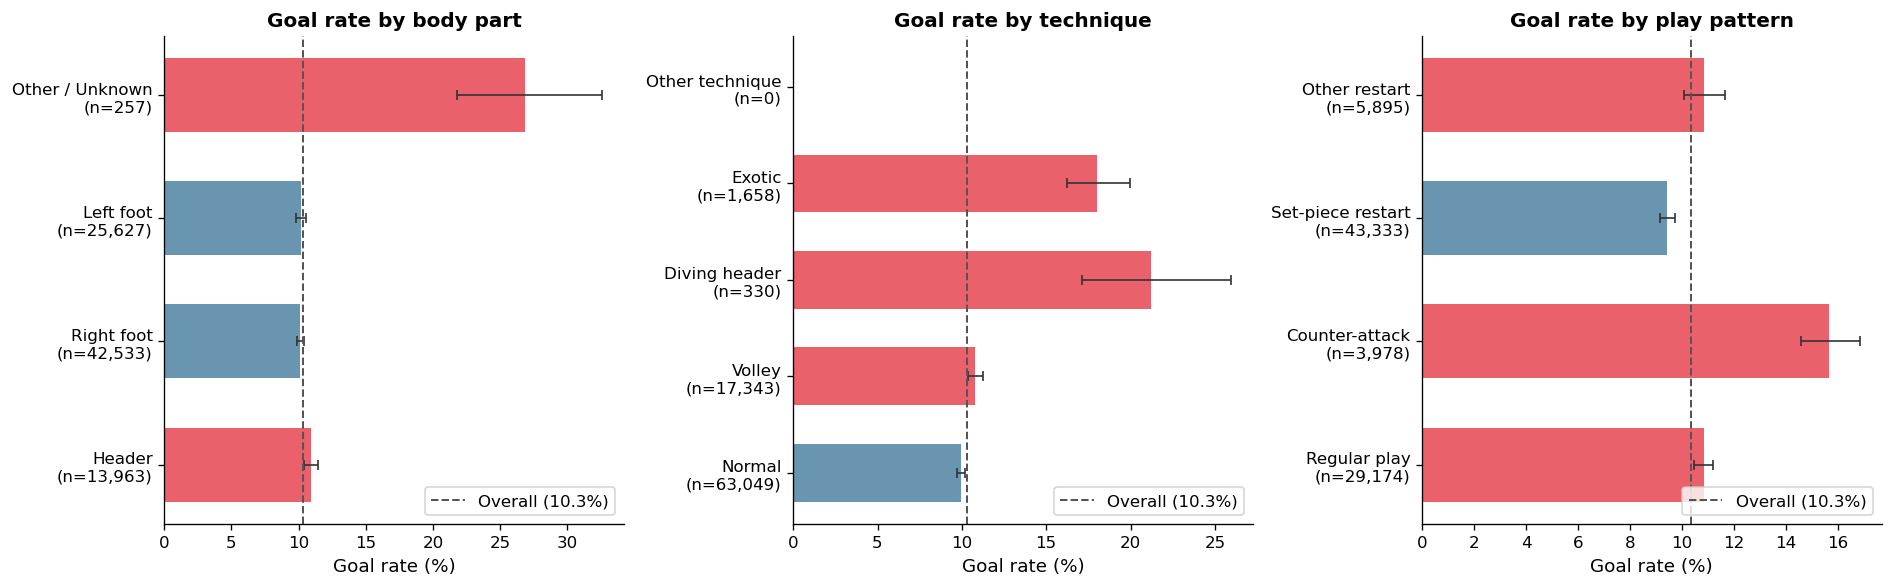

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Body part
goal_rate_bars(axes[0], [
    ("Header",       df["is_header"] == 1),
    ("Right foot",   df["is_right_foot"] == 1),
    ("Left foot",    df["is_left_foot"] == 1),
    ("Other / Unknown", df["is_other_bodypart"] == 1),
], "Goal rate by body part", baseline)

# Technique
goal_rate_bars(axes[1], [
    ("Normal",       df["is_normal_technique"] == 1),
    ("Volley",       df["is_volley"] == 1),
    ("Diving header",df["is_diving_header"] == 1),
    ("Exotic",       df["is_exotic_technique"] == 1),
    ("Other technique", (df[["is_normal_technique","is_volley","is_diving_header","is_exotic_technique"]].sum(axis=1) == 0)),
], "Goal rate by technique", baseline)

# Play pattern
goal_rate_bars(axes[2], [
    ("Regular play",       df["is_regular_play"] == 1),
    ("Counter-attack",     df["is_from_counter"] == 1),
    ("Set-piece restart",  df["is_from_set_piece_restart"] == 1),
    ("Other restart",      (df[["is_regular_play","is_from_counter","is_from_set_piece_restart"]].sum(axis=1) == 0)),
], "Goal rate by play pattern", baseline)

plt.tight_layout()
plt.savefig(FIGDIR / "03_goal_rate_categorical.png", bbox_inches="tight")
plt.show()

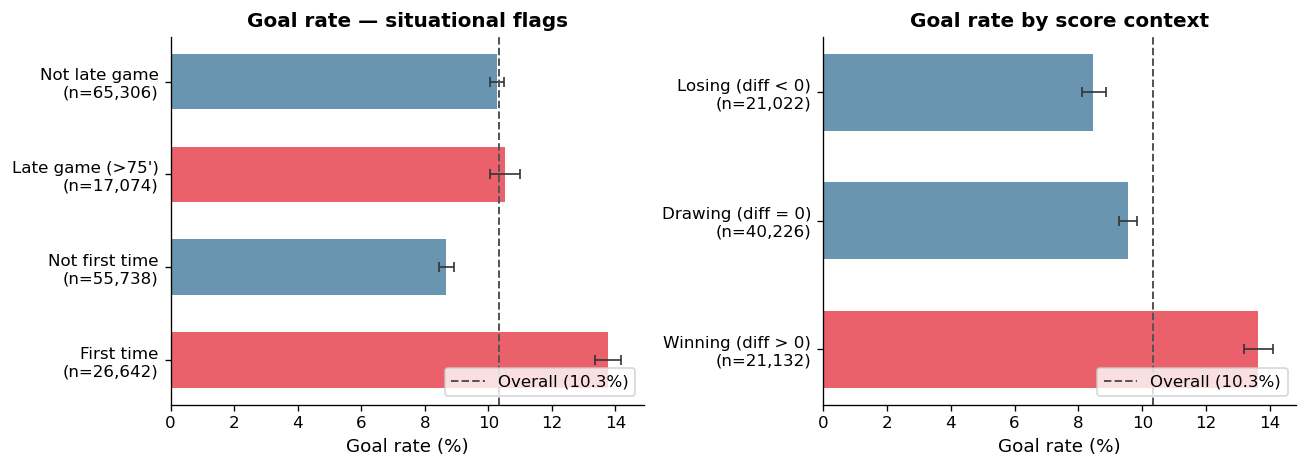

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Situational flags
goal_rate_bars(axes[0], [
    ("First time",   df["is_first_time"] == 1),
    ("Not first time", df["is_first_time"] == 0),
    ("Late game (>75')", df["is_late_game"] == 1),
    ("Not late game", df["is_late_game"] == 0),
], "Goal rate — situational flags", baseline)

# Score context
goal_rate_bars(axes[1], [
    ("Winning (diff > 0)",  df["score_diff_at_shot"] > 0),
    ("Drawing (diff = 0)",  df["score_diff_at_shot"] == 0),
    ("Losing (diff < 0)",   df["score_diff_at_shot"] < 0),
], "Goal rate by score context", baseline)

plt.tight_layout()
plt.savefig(FIGDIR / "03_goal_rate_situational.png", bbox_inches="tight")
plt.show()

---
## 2. Weak Foot Deep Dive

**The question**: is `is_weak_foot` a better abstraction than separate `is_right_foot` / `is_left_foot` flags?

**Theory**: The foot used per se should not matter much — a right-footed player shooting with their right foot and a left-footed player shooting with their left foot are both using their dominant foot. What should matter is whether the shot was taken with the **non-preferred** foot, which forces a less natural contact point and reduces accuracy.

If theory holds:
- Right foot ≈ Left foot (similar goal rates, once you strip out the weak-foot effect)
- Strong foot > Weak foot (preferred-foot shots convert more)
- Adding `is_right_foot` or `is_left_foot` on top of `is_weak_foot` should add near-zero signal

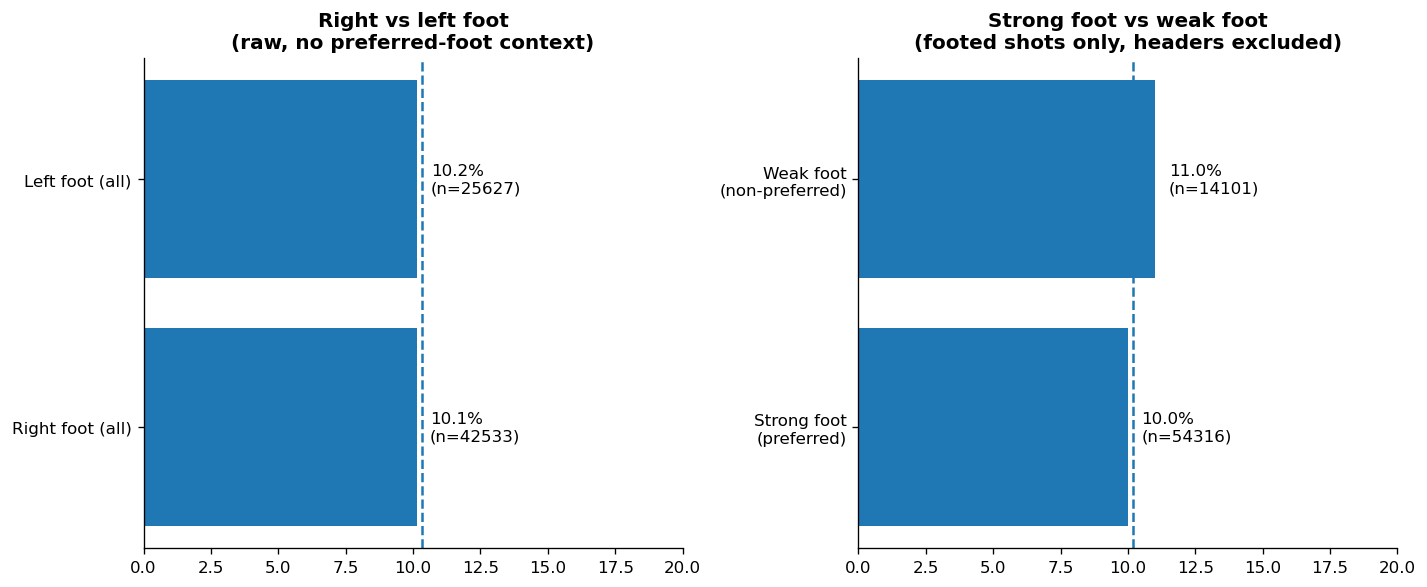

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def goal_rate_bars(ax, data, groups, title, baseline):
    labels, rates, counts = [], [], []

    for label, mask in groups:
        sub = data[mask]  # ✅ always aligned now
        n = len(sub)
        g = sub["is_goal"].sum()

        rate = (g / n) * 100 if n > 0 else 0

        labels.append(label)
        rates.append(rate)
        counts.append(n)

    # Plot
    y = np.arange(len(labels))
    ax.barh(y, rates)

    # Labels
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(title)

    # Baseline line
    ax.axvline(baseline * 100, linestyle="--")

    # Annotate counts
    for i, (rate, n) in enumerate(zip(rates, counts)):
        ax.text(rate + 0.5, i, f"{rate:.1f}%\n(n={n})", va="center")



# --- Create figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT: raw foot comparison ---
baseline = df["is_goal"].mean()

goal_rate_bars(
    axes[0],
    df,
    [
        ("Right foot (all)", df["is_right_foot"] == 1),
        ("Left foot (all)",  df["is_left_foot"] == 1),
    ],
    "Right vs left foot\n(raw, no preferred-foot context)",
    baseline
)

axes[0].set_xlim(0, 20)


# --- RIGHT: strong vs weak foot (exclude headers) ---
footed = df[df["is_header"] == 0].copy()

goal_rate_bars(
    axes[1],
    footed,
    [
        ("Strong foot\n(preferred)",  footed["is_weak_foot"] == 0),
        ("Weak foot\n(non-preferred)", footed["is_weak_foot"] == 1),
    ],
    "Strong foot vs weak foot\n(footed shots only, headers excluded)",
    footed["is_goal"].mean()
)

axes[1].set_xlim(0, 20)


# --- Final layout ---
plt.tight_layout()
plt.savefig(FIGDIR / "03_weak_foot_analysis.png", bbox_inches="tight")
plt.show()

In [8]:
# Cross-table: foot used x preferred foot -> goal rate
# This is the cleanest way to see if foot identity matters beyond weak-foot flag
footed_all = df[df["is_header"] == 0].copy()
footed_all["foot_used"] = np.where(footed_all["is_right_foot"] == 1, "Right", "Left")
footed_all["foot_type"] = np.where(footed_all["is_weak_foot"] == 1, "Weak", "Strong")

ct = footed_all.groupby(["foot_used", "foot_type"])["is_goal"].agg(["mean", "count"]).reset_index()
ct["goal_rate_pct"] = (ct["mean"] * 100).round(2)
ct = ct.rename(columns={"count": "shots"})
ct[["foot_used", "foot_type", "shots", "goal_rate_pct"]]

,foot_used,foot_type,shots,goal_rate_pct
0,Left,Strong,14722,9.80
1,Left,Weak,11162,11.02
2,Right,Strong,39594,10.07
3,Right,Weak,2939,10.99


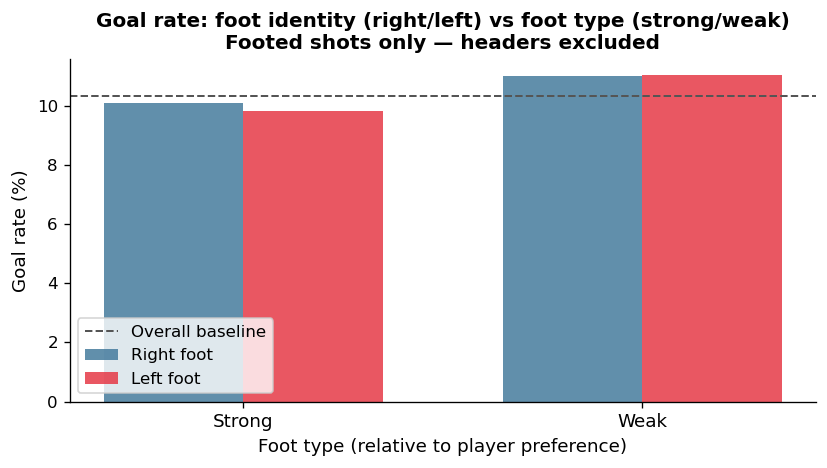


Interpretation:
  If right ≈ left within each row -> foot identity doesn't matter beyond weak-foot flag.
  If strong > weak within each column -> the weak-foot penalty is real.


In [9]:
# Visualise the cross-table as a grouped bar chart
fig, ax = plt.subplots(figsize=(7, 4))

pivot = ct.pivot(index="foot_type", columns="foot_used", values="goal_rate_pct")
x = np.arange(len(pivot.index))
w = 0.35
ax.bar(x - w/2, pivot["Right"], width=w, label="Right foot", color="#457b9d", alpha=0.85)
ax.bar(x + w/2, pivot["Left"],  width=w, label="Left foot",  color="#e63946", alpha=0.85)
ax.axhline(df["is_goal"].mean() * 100, ls="--", color="#555", lw=1.2, label="Overall baseline")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=11)
ax.set_xlabel("Foot type (relative to player preference)")
ax.set_ylabel("Goal rate (%)")
ax.set_title("Goal rate: foot identity (right/left) vs foot type (strong/weak)\nFooted shots only — headers excluded")
ax.legend()

plt.tight_layout()
plt.savefig(FIGDIR / "03_foot_identity_vs_type.png", bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("  If right ≈ left within each row -> foot identity doesn't matter beyond weak-foot flag.")
print("  If strong > weak within each column -> the weak-foot penalty is real.")

---
## 3. Spatial Analysis

Distance and visible angle are the **foundation** of any xG model. A shot from 5 meters dead-centre is almost certain to score; a shot from 35 meters and wide has near-zero probability. These plots verify the features encode the expected geometry.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

goals    = df[df["is_goal"] == 1]
no_goals = df[df["is_goal"] == 0]

# Distance to goal — density
ax = axes[0]
bins = np.linspace(0, 55, 45)
ax.hist(no_goals["distance_to_goal"], bins=bins, density=True,
        color=NO_GOAL_COLOR, alpha=0.6, label="No goal")
ax.hist(goals["distance_to_goal"],    bins=bins, density=True,
        color=GOAL_COLOR, alpha=0.7, label="Goal")
ax.set_xlabel("Distance to goal (StatsBomb units)")
ax.set_ylabel("Density")
ax.set_title("Distance to goal\nGoals cluster close; non-goals spread far")
ax.legend()

# Visible angle — density
ax = axes[1]
bins = np.linspace(0, 70, 45)
ax.hist(no_goals["visible_angle"], bins=bins, density=True,
        color=NO_GOAL_COLOR, alpha=0.6, label="No goal")
ax.hist(goals["visible_angle"],    bins=bins, density=True,
        color=GOAL_COLOR, alpha=0.7, label="Goal")
ax.set_xlabel("Visible goal angle (degrees)")
ax.set_ylabel("Density")
ax.set_title("Visible goal angle\nGoals from wider angles; non-goals from narrow ones")
ax.legend()

plt.tight_layout()
plt.savefig(FIGDIR / "03_spatial_distributions.png", bbox_inches="tight")
plt.show()

In [ ]:
# Goal rate by distance bins — shows the non-linear relationship
df["dist_bin"] = pd.cut(df["distance_to_goal"], bins=np.arange(0, 56, 3), right=False)
dist_stats = (
    df.groupby("dist_bin", observed=True)["is_goal"]
    .agg(["mean", "count"])
    .reset_index()
)
dist_stats["mid"] = dist_stats["dist_bin"].apply(lambda b: b.mid)
dist_stats = dist_stats[dist_stats["count"] >= 50]  # drop sparse bins

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(dist_stats["mid"], dist_stats["count"], width=2.6,
        color="#adb5bd", alpha=0.5, label="Shot count")
ax2.plot(dist_stats["mid"], dist_stats["mean"] * 100,
         color=GOAL_COLOR, lw=2.2, marker="o", ms=4, label="Goal rate %")
ax2.axhline(df["is_goal"].mean() * 100, color="#555", ls="--", lw=1.2)

ax1.set_xlabel("Distance to goal (StatsBomb units)")
ax1.set_ylabel("Number of shots", color="#555")
ax2.set_ylabel("Goal rate (%)", color=GOAL_COLOR)
ax2.tick_params(axis="y", colors=GOAL_COLOR)
ax1.set_title("Goal rate and shot volume by distance\nNon-linear decay — justifies distance as a core feature")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

df.drop(columns=["dist_bin"], inplace=True)
plt.tight_layout()
plt.savefig(FIGDIR / "03_goal_rate_by_distance.png", bbox_inches="tight")
plt.show()

In [ ]:
# Shot geography: pitch heatmap of goal rate
# Divide the pitch into a grid; compute goal rate per cell

def draw_pitch(ax, pitch_color="#f8f8f8", line_color="#333", lw=1.2):
    """Draw a StatsBomb 120x80 pitch outline on the given axes."""
    ax.set_facecolor(pitch_color)
    # Pitch outline
    ax.add_patch(patches.Rectangle((0, 0), 120, 80, fill=False, ec=line_color, lw=lw))
    # Halfway line
    ax.plot([60, 60], [0, 80], color=line_color, lw=lw)
    # Centre circle
    ax.add_patch(patches.Circle((60, 40), 10, fill=False, ec=line_color, lw=lw))
    ax.plot(60, 40, "o", color=line_color, ms=2)
    # Penalty areas
    ax.add_patch(patches.Rectangle((102, 18), 18, 44, fill=False, ec=line_color, lw=lw))
    ax.add_patch(patches.Rectangle((0, 18), 18, 44, fill=False, ec=line_color, lw=lw))
    # 6-yard boxes
    ax.add_patch(patches.Rectangle((114, 30), 6, 20, fill=False, ec=line_color, lw=lw))
    ax.add_patch(patches.Rectangle((0, 30), 6, 20, fill=False, ec=line_color, lw=lw))
    # Goals
    ax.add_patch(patches.Rectangle((120, 36), 2, 8, fill=False, ec=line_color, lw=lw))
    ax.add_patch(patches.Rectangle((-2, 36), 2, 8, fill=False, ec=line_color, lw=lw))
    # Penalty spots
    ax.plot(108, 40, "o", color=line_color, ms=2)
    ax.plot(12, 40, "o", color=line_color, ms=2)
    ax.set_xlim(-3, 123)
    ax.set_ylim(-3, 83)
    ax.set_aspect("equal")
    ax.axis("off")

# Focus on attacking half (x > 60) where all shots occur
shot_half = df[df["location_x"] > 60].copy()

# Bin into a grid
x_bins = np.linspace(60, 122, 32)
y_bins = np.linspace(0, 80, 22)

shot_half["x_bin"] = pd.cut(shot_half["location_x"], bins=x_bins, labels=False)
shot_half["y_bin"] = pd.cut(shot_half["location_y"], bins=y_bins, labels=False)

grid = shot_half.groupby(["x_bin", "y_bin"], observed=True)["is_goal"].agg(["mean", "count"]).reset_index()
grid = grid[grid["count"] >= 20]  # suppress very sparse cells

# Map bin indices back to coordinates
grid["x_mid"] = (x_bins[grid["x_bin"].astype(int)] + x_bins[grid["x_bin"].astype(int) + 1]) / 2
grid["y_mid"] = (y_bins[grid["y_bin"].astype(int)] + y_bins[grid["y_bin"].astype(int) + 1]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shot density
draw_pitch(axes[0])
sc = axes[0].scatter(
    grid["x_mid"], grid["y_mid"],
    c=grid["count"], cmap="Blues",
    s=60, alpha=0.85, marker="s",
    vmin=0, vmax=grid["count"].quantile(0.95),
)
plt.colorbar(sc, ax=axes[0], shrink=0.6, label="Shot count")
axes[0].set_title("Shot density\n(open-play StatsBomb shots)")

# Goal rate heatmap
draw_pitch(axes[1])
sc2 = axes[1].scatter(
    grid["x_mid"], grid["y_mid"],
    c=grid["mean"] * 100, cmap="RdYlGn",
    s=60, alpha=0.9, marker="s",
    vmin=0, vmax=30,
)
plt.colorbar(sc2, ax=axes[1], shrink=0.6, label="Goal rate (%)")
axes[1].set_title("Goal rate by pitch zone\n(cells with < 20 shots hidden)")

plt.suptitle("Shot geography — attacking half", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGDIR / "03_shot_geography.png", bbox_inches="tight")
plt.show()

In [ ]:
# Distance vs visible angle scatter — coloured by outcome
# Subsample for performance (80k points is dense)
sample = df.sample(n=15_000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
no_g = sample[sample["is_goal"] == 0]
g    = sample[sample["is_goal"] == 1]

ax.scatter(no_g["distance_to_goal"], no_g["visible_angle"],
           color=NO_GOAL_COLOR, alpha=0.15, s=6, label="No goal", rasterized=True)
ax.scatter(g["distance_to_goal"], g["visible_angle"],
           color=GOAL_COLOR, alpha=0.4, s=8, label="Goal", rasterized=True)

ax.set_xlabel("Distance to goal (units)")
ax.set_ylabel("Visible goal angle (degrees)")
ax.set_title("Distance vs visible angle\nGoals cluster bottom-left (close + wide angle)")
ax.legend(markerscale=3)

# Annotate the 'golden zone'
ax.annotate("Golden zone\n(close, wide angle)",
            xy=(8, 35), fontsize=9, color="#555",
            arrowprops=dict(arrowstyle="->", color="#555"),
            xytext=(18, 50))

plt.tight_layout()
plt.savefig(FIGDIR / "03_distance_vs_angle.png", bbox_inches="tight")
plt.show()

---
## 4. Feature Correlations

Two questions:
- **Between spatial features**: how much do `distance_to_goal`, `x_from_goal_line`, `distance_to_near_post`, and `distance_to_far_post` overlap? High correlation doesn't mean a feature is useless for tree models, but it does mean logistic regression coefficients will be unstable.
- **Feature → target**: does each feature point in the expected direction?

In [ ]:
from src.features.build import get_feature_list
import sys
sys.path.insert(0, str(ROOT))
from src.features.build import get_feature_list

all_features = get_feature_list("full")
spatial_features = [
    "distance_to_goal", "visible_angle", "distance_to_near_post",
    "distance_to_far_post", "x_from_goal_line", "is_central"
]

corr = df[spatial_features].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
    mask=mask, square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Spatial feature correlation matrix\n(lower triangle)")
plt.tight_layout()
plt.savefig(FIGDIR / "03_spatial_correlation.png", bbox_inches="tight")
plt.show()

print("\nNote: distance_to_goal and x_from_goal_line will be highly correlated —")
print("expected, since lateral position adds only residual variation.")
print("High correlation is fine for XGBoost; for logistic regression, consider")
print("dropping x_from_goal_line and keeping only distance_to_goal + visible_angle.")

In [ ]:
# Full feature correlation matrix (all 22 features)
full_corr = df[all_features].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(full_corr, dtype=bool), k=1)
sns.heatmap(
    full_corr, annot=False, cmap="RdBu_r", vmin=-1, vmax=1,
    mask=mask, square=True, linewidths=0.3, ax=ax,
    cbar_kws={"shrink": 0.5},
)
ax.set_title("Full feature correlation matrix (22 features)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "03_full_correlation_matrix.png", bbox_inches="tight")
plt.show()

In [ ]:
# Univariate feature → target correlations
target_corrs = (
    df[all_features + ["is_goal"]]
    .corr()["is_goal"]
    .drop("is_goal")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 8))
colors = [GOAL_COLOR if v > 0 else NO_GOAL_COLOR for v in target_corrs]
ax.barh(target_corrs.index[::-1], target_corrs.values[::-1], color=colors[::-1], alpha=0.82)
ax.axvline(0, color="#333", lw=0.8)
ax.set_xlabel("Pearson correlation with is_goal")
ax.set_title("Univariate feature → target correlation\nRed = positive (more = more goals), Blue = negative")

plt.tight_layout()
plt.savefig(FIGDIR / "03_feature_target_correlations.png", bbox_inches="tight")
plt.show()

print("\nTop features by absolute correlation with is_goal:")
print(target_corrs.head(10).to_string())

---
## 5. Summary & Key Takeaways

Use this cell to record what you observe after running the notebook.

In [ ]:
# Summary table: goal rate + shot count for every major subgroup
summary_rows = []

subgroups = {
    "Header":                df["is_header"] == 1,
    "Right foot":            df["is_right_foot"] == 1,
    "Left foot":             df["is_left_foot"] == 1,
    "Strong foot (footed)": (df["is_header"] == 0) & (df["is_weak_foot"] == 0),
    "Weak foot (footed)":   (df["is_header"] == 0) & (df["is_weak_foot"] == 1),
    "First time":            df["is_first_time"] == 1,
    "Not first time":        df["is_first_time"] == 0,
    "Normal technique":      df["is_normal_technique"] == 1,
    "Volley":                df["is_volley"] == 1,
    "Regular play":          df["is_regular_play"] == 1,
    "Counter-attack":        df["is_from_counter"] == 1,
    "Set-piece restart":     df["is_from_set_piece_restart"] == 1,
    "Late game (>75')": df["is_late_game"] == 1,
    "Winning":               df["score_diff_at_shot"] > 0,
    "Drawing":               df["score_diff_at_shot"] == 0,
    "Losing":                df["score_diff_at_shot"] < 0,
}

for name, mask in subgroups.items():
    sub = df[mask]
    n = len(sub)
    g = sub["is_goal"].sum()
    summary_rows.append({
        "subgroup": name,
        "shots": n,
        "goals": g,
        "goal_rate_%": round(g / n * 100, 2) if n > 0 else 0,
        "vs_baseline_pp": round(g / n * 100 - df["is_goal"].mean() * 100, 2) if n > 0 else 0,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("goal_rate_%", ascending=False)
summary_df